# Validation Results Inspection

Compares gyaradax outputs against GKW reference data for both adiabatic and kinetic electron cases.

In [1]:
import sys
import os
sys.path.append("..")

from gyaradax.bootstrap import init_jax
init_jax(device=6)

cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from gyaradax.plot_utils import plot_flux_trace, plot_spectra
from gyaradax.params import load_config
from gyaradax.utils import load_geometry

In [3]:
adiabatic_dirs = sorted(
    [d for d in os.listdir("..") if d.startswith("validation_outputs_")]
)
kinetic_dirs = sorted(
    [d for d in os.listdir("..") if d.startswith("validation_kinetic_")]
)
print(f"adiabatic: {adiabatic_dirs}")
print(f"kinetic: {kinetic_dirs}")

adiabatic: ['validation_outputs_iteration_13', 'validation_outputs_iteration_200']
kinetic: []


## 1. Adiabatic Flux Comparison
Single-species (ion) heat and momentum fluxes.

In [ ]:
os.makedirs("figs", exist_ok=True)

for out_dir in adiabatic_dirs:
    path = os.path.join("..", out_dir)
    flux_path = os.path.join(path, "fluxes.npz")
    growth_path = os.path.join(path, "growth.npz")

    if not os.path.exists(flux_path) or not os.path.exists(growth_path):
        print(f"skipping {out_dir}: missing .npz files")
        continue

    sim_flux = np.load(flux_path)["fluxes"]
    sim_time = np.load(growth_path)["time"]

    config_name = out_dir.replace("validation_outputs_", "")
    config_path = os.path.join("..", "configs", f"{config_name}.yaml")

    ref_time, ref_fluxes = None, None
    kx, ky = None, None
    title = config_name
    if os.path.exists(config_path):
        cfg = load_config(config_path)
        ref_dir = cfg.run.data_dir
        ref_time_path = os.path.join(ref_dir, "time.dat")
        ref_flux_path = os.path.join(ref_dir, "fluxes.dat")
        if os.path.exists(ref_time_path) and os.path.exists(ref_flux_path):
            ref_time = np.loadtxt(ref_time_path)
            ref_fluxes = np.loadtxt(ref_flux_path).T

        geom = load_geometry(ref_dir)
        kx = np.asarray(geom["kxrh"])
        ky = np.asarray(geom["krho"])

        q = float(geom["q"])
        shat = float(geom["shat"])
        eps = float(geom["eps"])
        rlt = float(np.asarray(geom["rlt"]).flat[0])
        title = (
            rf"$q={q:.2f}$, $\hat{{s}}={shat:.2f}$, "
            rf"$\varepsilon={eps:.2f}$, $R/L_T={rlt:.1f}$"
        )

    fig = plot_flux_trace(
        sim_time,
        sim_flux.T[[1, 2]],
        ref_time=ref_time,
        ref_fluxes=ref_fluxes[[1, 2]] if ref_fluxes is not None else None,
        labels=["Heat", "Momentum"],
        title=title,
    )
    fig.savefig(f"figs/fluxes_{config_name}.pdf")

    # spectra
    kx_spec_path = os.path.join(path, "kxspec.npz")
    ky_spec_path = os.path.join(path, "kyspec.npz")
    if (
        os.path.exists(kx_spec_path)
        and os.path.exists(ky_spec_path)
        and kx is not None
    ):
        avg_count = 80
        kx_spec_avg = np.mean(np.load(kx_spec_path)["kx_spec"][-avg_count:], axis=0)
        ky_spec_avg = np.mean(np.load(ky_spec_path)["ky_spec"][-avg_count:], axis=0)

        ref_kx_spec, ref_ky_spec = None, None
        ref_kx_path = os.path.join(ref_dir, "kxspec")
        ref_ky_path = os.path.join(ref_dir, "kyspec")
        if os.path.exists(ref_kx_path) and os.path.exists(ref_ky_path):
            ref_kx_spec = np.mean(np.loadtxt(ref_kx_path)[-avg_count * 3 :], axis=0)
            ref_ky_spec = np.mean(np.loadtxt(ref_ky_path)[-avg_count * 3 :], axis=0)

        fig_spec = plot_spectra(
            kx=kx,
            ky=ky,
            kx_spec=kx_spec_avg,
            ky_spec=ky_spec_avg,
            ref_kx_spec=ref_kx_spec,
            ref_ky_spec=ref_ky_spec,
        )
        fig_spec.savefig(f"figs/spectra_{config_name}.pdf")

## 2. Kinetic Electron Flux Comparison
Two-species (ion + electron) heat fluxes, side-by-side.

In [ ]:
KINETIC_REF_DIR = "/restricteddata/ukaea/gyrokinetics/raw/kinetic_electrons"

for out_dir in kinetic_dirs:
    path = os.path.join("..", out_dir)
    case_name = out_dir.replace("validation_kinetic_", "")
    ref_dir = os.path.join(KINETIC_REF_DIR, case_name)

    flux_path = os.path.join(path, "fluxes.npz")
    growth_path = os.path.join(path, "growth.npz")

    if not os.path.exists(flux_path) or not os.path.exists(growth_path):
        print(f"skipping {out_dir}: missing .npz files")
        continue

    # fluxes shape: (n_entries, nsp, 3) for kinetic
    fluxes_data = np.load(flux_path)["fluxes"]
    sim_times = np.load(growth_path)["time"]
    sim_eflux_ion = fluxes_data[:, 0, 1]
    sim_eflux_elec = fluxes_data[:, 1, 1]

    ref_time = np.loadtxt(os.path.join(ref_dir, "time.dat"))
    ref_fluxes = np.loadtxt(os.path.join(ref_dir, "fluxes.dat"))

    # build title from geometry scalars
    geom = load_geometry(ref_dir)
    q = float(geom["q"])
    shat = float(geom["shat"])
    eps = float(geom["eps"])
    rlt = float(np.asarray(geom["rlt"]).flat[0])
    title = (
        rf"$q={q:.2f}$, $\hat{{s}}={shat:.2f}$, "
        rf"$\varepsilon={eps:.2f}$, $R/L_T={rlt:.1f}$"
    )

    # ion and electron eflux side by side
    fig, (ax_ion, ax_elec) = plt.subplots(1, 2, figsize=(12, 3), sharex=True)

    ax_ion.plot(sim_times, sim_eflux_ion, color="#24B6AD", lw=1.5, label="gyaradax")
    ax_ion.plot(ref_time, ref_fluxes[:, 1], "k--", alpha=0.7, lw=1.2, label="GKW")
    ax_ion.set_ylabel("eflux")
    ax_ion.set_title("ion")
    ax_ion.legend(frameon=False)
    ax_ion.grid(True, axis="y")

    ax_elec.plot(sim_times, sim_eflux_elec, color="#9B51E0", lw=1.5, label="gyaradax")
    ax_elec.plot(ref_time, ref_fluxes[:, 4], "k--", alpha=0.7, lw=1.2, label="GKW")
    ax_elec.set_title("electron")
    ax_elec.legend(frameon=False)
    ax_elec.grid(True, axis="y")

    for ax in (ax_ion, ax_elec):
        ax.set_xlabel(r"time $[v_{th}/R]$")

    fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"figs/kinetic_fluxes_{case_name}.pdf")
    plt.show()

    # spectra if available
    kx_spec_path = os.path.join(path, "kxspec.npz")
    ky_spec_path = os.path.join(path, "kyspec.npz")
    if os.path.exists(kx_spec_path) and os.path.exists(ky_spec_path):
        kx = np.asarray(geom["kxrh"])
        ky = np.asarray(geom["krho"])

        avg_count = min(80, len(np.load(kx_spec_path)["kx_spec"]))
        kx_spec_avg = np.mean(np.load(kx_spec_path)["kx_spec"][-avg_count:], axis=0)
        ky_spec_avg = np.mean(np.load(ky_spec_path)["ky_spec"][-avg_count:], axis=0)

        ref_kx_spec, ref_ky_spec = None, None
        ref_kx_path = os.path.join(ref_dir, "kxspec")
        ref_ky_path = os.path.join(ref_dir, "kyspec")
        if os.path.exists(ref_kx_path) and os.path.exists(ref_ky_path):
            ref_kx_spec = np.mean(np.loadtxt(ref_kx_path)[-avg_count * 3 :], axis=0)
            ref_ky_spec = np.mean(np.loadtxt(ref_ky_path)[-avg_count * 3 :], axis=0)

        fig_spec = plot_spectra(
            kx=kx,
            ky=ky,
            kx_spec=kx_spec_avg,
            ky_spec=ky_spec_avg,
            ref_kx_spec=ref_kx_spec,
            ref_ky_spec=ref_ky_spec,
        )
        fig_spec.savefig(f"figs/kinetic_spectra_{case_name}.pdf")
        plt.show()

/tmp/ipykernel_1402520/882200353.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


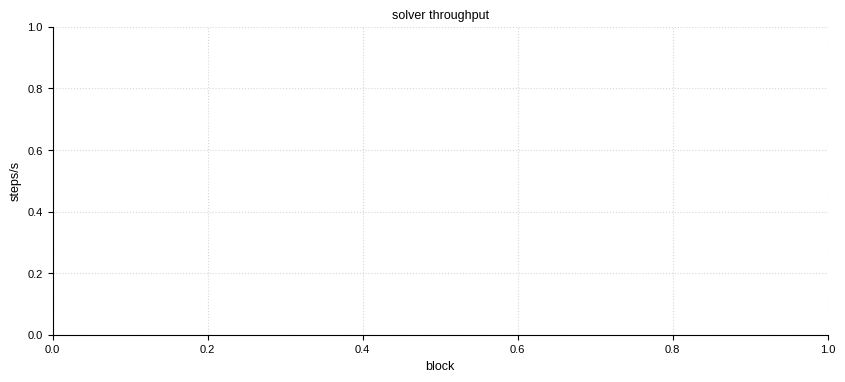

In [6]:
## 3. Performance

fig, ax = plt.subplots(figsize=(10, 4))
for out_dir in adiabatic_dirs:
    perf_path = os.path.join("..", out_dir, "performance.npz")
    if os.path.exists(perf_path):
        perf = np.load(perf_path)
        if "steps_per_sec" in perf:
            name = out_dir.replace("validation_outputs_", "")
            ax.plot(perf["steps_per_sec"], "o-", ms=2, label=name)

ax.set_xlabel("block")
ax.set_ylabel("steps/s")
ax.set_title("solver throughput")
ax.legend(frameon=False)
ax.grid(True, linestyle=":", alpha=0.5)
plt.show()